## 2. Plotting the dynamic sea level

This note plots dynamic sea level aggregated data. [Additionally we load a table and group the result by average melting in 2100, 2200 and 2300 and and melt parameterization.]

In [15]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n

import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
sns.set_context("paper")
sns.set_style("whitegrid")

computed_dir = '/home/sxc581/mnt/ncihome/ismip6_hackathon/ComputedScalars'
computed_dir_helene = '/home/sxc581/mnt/ncihome/ismip6_hackathon/ComputedScalarsHelene'
figures_dir = '/home/sxc581/mnt/ncihome/ismip6_hackathon/figures'


In [17]:
# Get: Group, Model, Experiment, Climate forcing, Model setup, fileID, Main submission, Melt parameterisation, Melt parameters
df = pd.read_csv('Metadata.txt', usecols=[1,2,3,4,5,6,7,8,9,10,11,12,13])
df['melt2100'] = 0
df['melt2200'] = 0
df['melt2300'] = 0

# Define constants for conversion
rhow= 1028
oceanarea = 361e6*1000**2 # m2 

# Set time var for all data
time=np.arange(2015,2300) # common start/end time
i_2100= np.argwhere(time == 2099)[0][0]
i_2200= np.argwhere(time == 2199)[0][0]
i_2300= np.argwhere(time == 2299)[0][0]

expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
expnames_plot = ['CCSM4','HadGEM2','CESM2','UKESM']

In [18]:
# function to make all timeseries same start & end date
def subset_all(time,data):
    i2016 = np.argwhere(time == 2016)[0][0]
    i2299 = np.argwhere(time == 2299)[0][0]
    timenew = time[i2016:i2299+1]
    datanew = data[i2016:i2299+1]
    return timenew, datanew

## Get the DSLC, anomaly wrt control
Output the data into the dictionary dic_dslc and dic_dslctime

In [19]:
# Create a dictionary to store the lists
valuesend_dict = {expname: [] for expname in expnames}

# Loop to populate dictionary with dslc data from all models and experiments
dic_dslc = {}
dic_dslc_wais = {}
dic_dslc_eais = {}
dic_dslc_ap = {}

# use a list of dictionaries for the sectors rather than a dict for each
# here an empty list of length 18 which gets filled subsequently with the 
dic_dslc_secs = [{} for _ in range(18)]

dic_dslctime = {}

for iexp, expname in enumerate(expnames):
    # create new dictionary for each experiment; key is model
    dic_all = {}
    dic_alltime = {}
    
    dic_wais = {}
    dic_eais = {}
    dic_ap = {}

    # list of empty dictionaries of length 18
    dic_secs = [{} for _ in range(18)]

    file_exp = os.listdir(f"{computed_dir}/{expname}/dslc_anom")
    file_exp = [file for file in file_exp if len(file) >= 3]

    # remove some files if less than 3 datasets in experiment
    for ifile in reversed(range(len(file_exp))):
        if len(file_exp[ifile]) < 3:
            del file_exp[ifile]

    # dictionary referenced by model run name
    for ifile in range(len(file_exp)):
        filename = f"{computed_dir}/{expname}/dslc_anom/{file_exp[ifile]}"
        modelrun = file_exp[ifile].split('AIS_')[-1].split(expname)[0]
        modelrun = modelrun[:-1]

        # convert Gt to mm water equiv gmsl
        d = xr.open_dataset(filename,decode_times=False )
        data_all = -1 * d.dslc_anom.values*1e12/rhow/oceanarea # all Antarctica
        time = d.time.values
        
        data_wais = -1 * d.dslc_anom_region_1.values*1e12/rhow/oceanarea # just WAIS
        data_eais = -1 * d.dslc_anom_region_2.values*1e12/rhow/oceanarea # just EAIS
        data_ap = -1 * d.dslc_anom_region_3.values*1e12/rhow/oceanarea # just Ant Peninsula

        # another empty list to fill the time series
        data_secs = [None] * 18

        # fill the empty list with all the sectors
        for i_sec in range(18):
            data_secs[i_sec] = -1 * d['dslc_anom_sector_' + str(i_sec+1)].values * 1e12 / rhow / oceanarea
        
        # check: are dslc and time variables same length?
        if len(data_all) != len(time):
            print('Error: dslc \n')
            print(filename)
            break

        # subset so all datasets are same length
        time,data_all = subset_all(time,data_all)
        time,data_wais = subset_all(time,data_wais)
        time,data_eais = subset_all(time,data_eais)
        time,data_ap = subset_all(time,data_ap)

        for i_sec in range(18):
            time, data_secs[i_sec] = subset_all(time, data_secs[i_sec])
        
        dic_all[modelrun] = data_all
        dic_alltime[modelrun] = time
        dic_wais[modelrun] = data_wais
        dic_eais[modelrun] = data_eais
        dic_ap[modelrun] = data_ap

        # add the data to the relevant dictionaries
        for i_sec in range(18):
            dic_secs[i_sec][modelrun] = data_secs[i_sec]
                
        # remove some datasets if file list for each is not complete
        if ("NORCE" in file_exp[ifile] and "NORCE_CISM3-MAR364-ERA-t1-non" not in file_exp[ifile]) or \
           ("VUW" in file_exp[ifile] and "VUW_PISM1_e" not in file_exp[ifile]) or \
           ("DOE" in file_exp[ifile] and "DOE_MALI_4km" not in file_exp[ifile]) or \
           ("NCAR" in file_exp[ifile] and "NCAR_CISM2" not in file_exp[ifile]) or \
           ("LSCE" in file_exp[ifile] and "LSCE_GRISLI_e" not in file_exp[ifile]) or \
           ("ULB" in file_exp[ifile] and "ULB_fETISh-KoriBU1" not in file_exp[ifile]) or \
           ("IMAU" in file_exp[ifile] and "IMAU_UFEMISM1" not in file_exp[ifile]):
            pass
        else:
            if len(data_all) > 250:
                valuesend_dict[expname].append(data_all[time.size-1])
                df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'dslc2100'] = data_all[i_2100-5:i_2100+5].mean()
                df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'dslc2200'] = data_all[i_2200-5:i_2200+5].mean()
                df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'dslc2300'] = data_all[i_2300-5:i_2300].mean()

            else:
               print("Error: " + df['Experiment'] + " is too short. Excluding from file list")

    # save all data from each experiment as sub-dictionary
    dic_dslc[expname]=dic_all
    dic_dslctime[expname]=dic_alltime
    
    dic_dslc_wais[expname]=dic_wais
    dic_dslc_eais[expname]=dic_eais
    dic_dslc_ap[expname]=dic_ap

    for i_sec in range(18):
        dic_dslc_secs[i_sec][expname] = dic_secs[i_sec]

    

## Get the grounded area anomaly
Output the data to the dictionaries dic_ga and dic_gatime

In [20]:
# Create a dictionary to store the lists
valuesend_dict = {expname: [] for expname in expnames}
dic_ga = {}
dic_gatime = {}
dic_ga_wais = {}
dic_ga_eais = {}
dic_ga_ap = {}

dic_ga_secs = [{} for _ in range(18)]

# dic_ga_sec1 = {}
# dic_ga_sec2 = {}
# dic_ga_sec3 = {}

# Loop to populate dictionary with info from all models and experiments
for iexp, expname in enumerate(expnames):
    # create new dictionary for each experiment; key is model
    dic_all = {}
    dic_alltime = {}
    dic_wais = {}
    dic_eais = {}
    dic_ap = {}

    dic_secs = [{} for _ in range(18)]

    file_exp = os.listdir(f"{computed_dir}/{expname}/iareagr_anom")
    file_exp = [file for file in file_exp if len(file) >= 3]

    # remove some files if less than 3 datasets in experiment
    for ifile in reversed(range(len(file_exp))):
        if len(file_exp[ifile]) < 3:
            del file_exp[ifile]

    # dictionary referenced by model run name
    for ifile in range(len(file_exp)):
        filename = f"{computed_dir}/{expname}/iareagr_anom/{file_exp[ifile]}"
        modelrun = file_exp[ifile].split('AIS_')[-1].split(expname)[0]
        modelrun = modelrun[:-1]

        # Read in grounded area data over time and geographical region
        d = xr.open_dataset(filename,decode_times = False)
        data_all = d.iareagr_anom.values # all Antarctica
        time = d.time.values
        data_wais = d.iareagr_anom_region_1.values # WAIS
        data_eais = d.iareagr_anom_region_2.values # EAIS
        data_ap = d.iareagr_anom_region_3.values # Ant Penin

        # another empty list to fill the time series
        data_secs = [None] * 18

        # fill the empty list with all the sectors
        for i_sec in range(18):
            data_secs[i_sec] = d['iareagr_anom_sector_' + str(i_sec+1)].values
        
        # subset so all datasets are same length
        time,data_all  = subset_all(time,data_all)
        time,data_wais = subset_all(time,data_wais)
        time,data_eais = subset_all(time,data_eais)
        time,data_ap   = subset_all(time,data_ap)

        for i_sec in range(18):
            time, data_secs[i_sec] = subset_all(time, data_secs[i_sec])
        
        dic_all[modelrun]  = data_all
        dic_alltime[modelrun] = time
        dic_wais[modelrun] = data_wais
        dic_eais[modelrun] = data_eais
        dic_ap[modelrun] = data_ap

        for i_sec in range(18):
            dic_secs[i_sec][modelrun] = data_secs[i_sec]
        
        # remove some datasets if file list for each is not complete
        if ("NORCE" in file_exp[ifile] and "NORCE_CISM3-MAR364-ERA-t1-non" not in file_exp[ifile]) or \
           ("VUW" in file_exp[ifile] and "VUW_PISM1_e" not in file_exp[ifile]) or \
           ("LSCE" in file_exp[ifile] and "LSCE_GRISLI_e" not in file_exp[ifile]):
            pass
        else:
            if len(data_all) > 250:
                valuesend_dict[expname].append(data_all[time.size-1])
                df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'ga2100'] = data_all[i_2100-5:i_2100+5].mean()
                df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'ga2200'] = data_all[i_2200-5:i_2200+5].mean()
                df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'ga2300'] = data_all[i_2300-5:i_2300].mean()
      
            else:
                print("Error: " + df['Experiment'] + " is too short. Excluding from file list")
                
        # save all data from each experiment as sub-dictionary
        dic_ga[expname] = dic_all
        dic_gatime[expname] = dic_alltime
        
        dic_ga_wais[expname] = dic_wais
        dic_ga_eais[expname] = dic_eais
        dic_ga_ap[expname] = dic_ap

        for i_sec in range(18):
            dic_ga_secs[i_sec][expname] = dic_secs[i_sec]

        

## Plot the dynamic sea level contribution anomaly over time

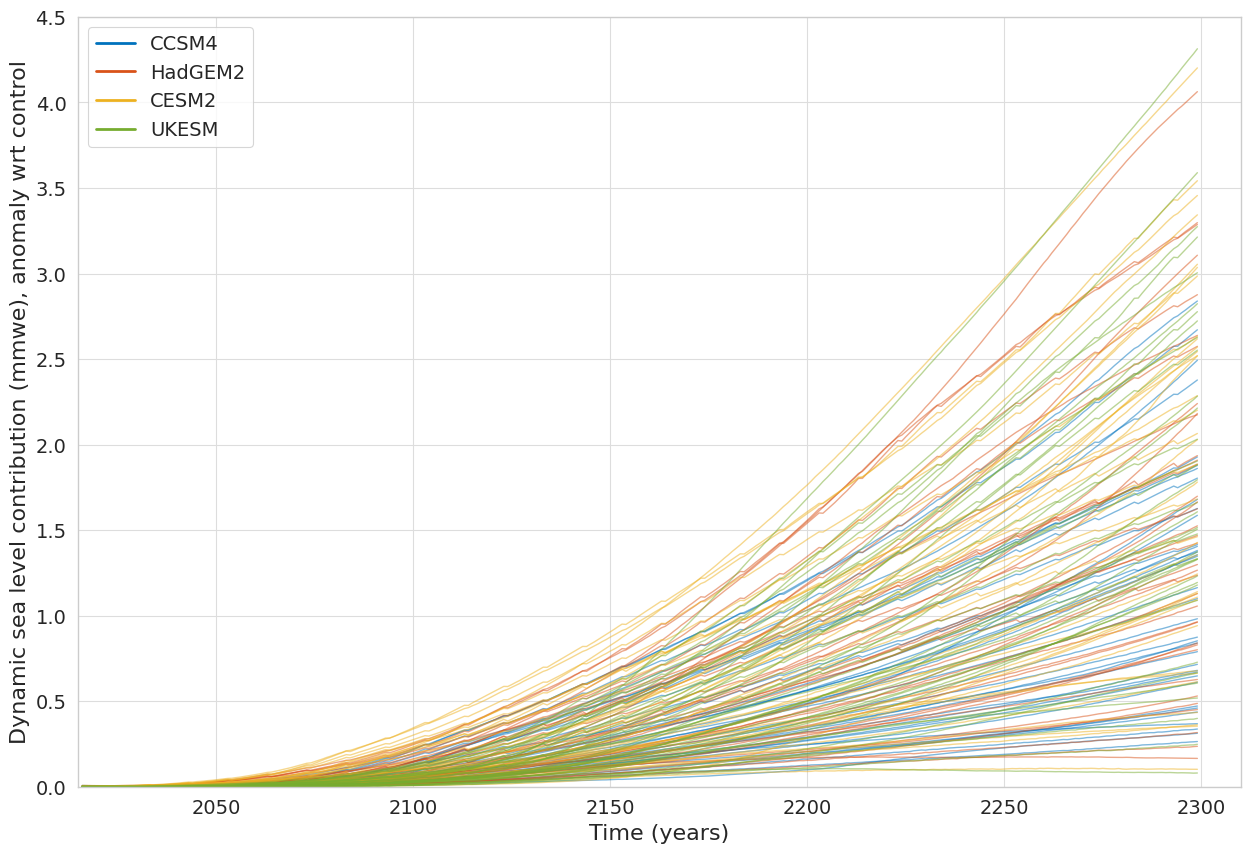

In [28]:
f,ax = plt.subplots(1,1, figsize = (15,10))
colors = np.array([[0, 0.4470, 0.7410], [0.8500, 0.3250, 0.0980], [0.9290, 0.6940, 0.1250], [0.4660, 0.6740, 0.1880]])

for iexp, expname in enumerate(dic_dslc):
    climate_forcing = dic_dslc[expname]
    climate_time = dic_dslctime[expname]
    dslcmean = 0
    for cgcm in climate_forcing:
        plt.plot(climate_time[cgcm], climate_forcing[cgcm], linewidth=1, color=colors[iexp, :], alpha=0.5)
    
    x = [2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp, 2303 + 2.5 * iexp]
    y = [np.min(valuesend_dict[expname]), np.max(valuesend_dict[expname]),
         np.max(valuesend_dict[expname]), np.min(valuesend_dict[expname])]
    plt.fill(x, y, [-1, -1, -1, -1], color=colors[iexp, :], edgecolor=colors[iexp, :])

ax.set_ylim([0, 4.5])
ax.set_xlabel('Time (years)', fontsize=16)
ax.set_ylabel('Dynamic sea level contribution (mmwe), anomaly wrt control', fontsize=16)

legend_lines = [mlines.Line2D([], [], color=colors[i], linewidth=2, label=expname) for i, expname in enumerate(expnames_plot)]
ax.legend(handles=legend_lines, loc='upper left', fontsize=14)

ax.set_xlim([2015, 2310])
ax.tick_params(labelsize=14)
ax.grid(which='major', color='#DDDDDD', linewidth=0.8)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
#plt.savefig(figures_dir + '/dslc_anom_2300.pdf', format='pdf', bbox_inches='tight')
plt.show()



# Plot the grounded area anomaly over time

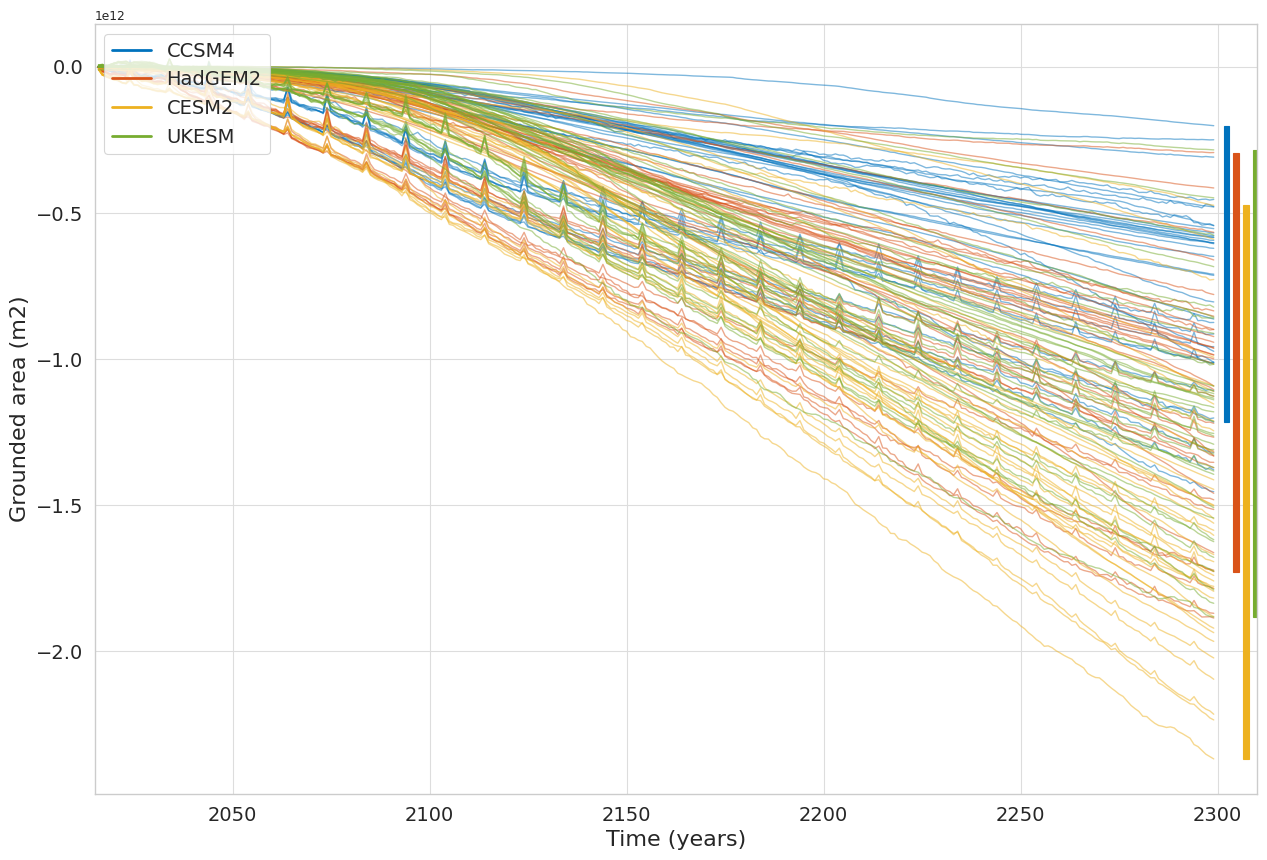

In [29]:
f,ax = plt.subplots(1,1, figsize = (15,10))

for iexp, expname in enumerate(dic_ga):
    climate_forcing = dic_ga[expname]
    climate_time = dic_gatime[expname]
    gamean = 0
    for cgcm in climate_forcing:
        plt.plot(climate_time[cgcm], climate_forcing[cgcm], linewidth=1, color=colors[iexp, :], alpha=0.5)
        #print(climate_forcing[cgcm].shape)
        #dslcmean += climate_forcing[cgcm]
    #dslcmean = dslcmean / len(climate_forcing)
    #plt.plot(climate_time[cgcm], dslcmean, linewidth=1, color=colors[iexp, :])
    
    x = [2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp, 2303 + 2.5 * iexp]
    y = [np.min(valuesend_dict[expname]), np.max(valuesend_dict[expname]),
         np.max(valuesend_dict[expname]), np.min(valuesend_dict[expname])]
    plt.fill(x, y, [-1, -1, -1, -1], color=colors[iexp, :], edgecolor=colors[iexp, :])

#ax.set_ylim([1e13, 1.4e13])
ax.set_xlabel('Time (years)', fontsize=16)
ax.set_ylabel('Grounded area (m2)', fontsize=16)

legend_lines = [mlines.Line2D([], [], color=colors[i], linewidth=2, label=expname) for i, expname in enumerate(expnames_plot)]
ax.legend(handles=legend_lines, loc='upper left', fontsize=14)

ax.set_xlim([2015, 2310])
ax.tick_params(labelsize=14)
ax.grid(which='major', color='#DDDDDD', linewidth=0.8)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
#plt.savefig(figures_dir + '/dslc_anom_2300.pdf', format='pdf', bbox_inches='tight')
plt.show()



# Plot grounded area by sector

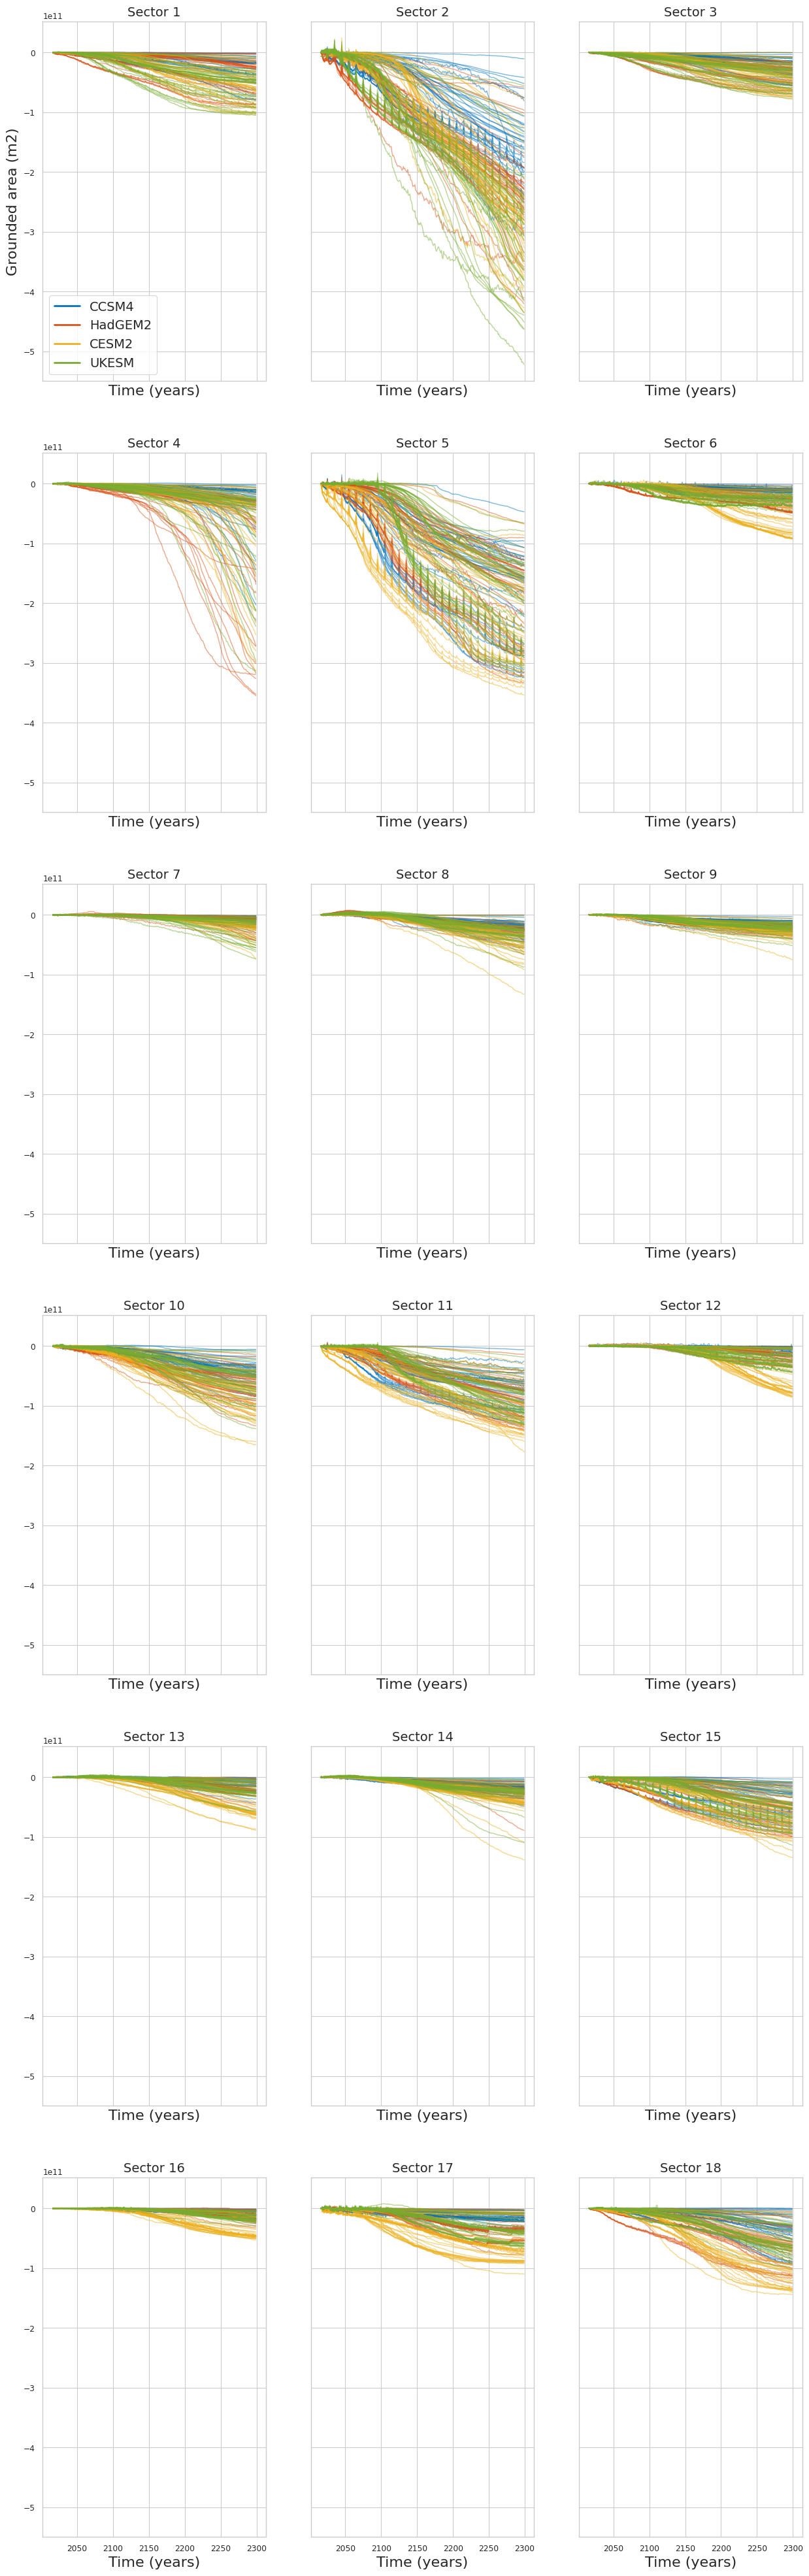

In [30]:
f, ax = plt.subplots(6, 3, figsize=(15, 50), sharey=True, sharex=True)
ax = ax.flatten()
# loop through sectors

for i_sec in range(18):
    for iexp, expname in enumerate(dic_ga):
        climate_forcing = dic_ga_secs[i_sec][expname]
        climate_time = dic_gatime[expname]
        #gamean = 0
        for cgcm in climate_forcing:
            ax[i_sec].plot(climate_time[cgcm], climate_forcing[cgcm], linewidth=1, color=colors[iexp, :], alpha=0.5)
        ax[i_sec].set_xlabel('Time (years)', fontsize=16)

    ax[i_sec].set_title('Sector ' + str(i_sec+1), fontsize=14)

ax[0].set_ylabel('Grounded area (m2)', fontsize=16)


legend_lines = [mlines.Line2D([], [], color=colors[i], linewidth=2, label=expname) for i, expname in enumerate(expnames_plot)]
ax[0].legend(handles=legend_lines, loc='lower left', fontsize=14)
plt.show()

## Plot grounded area vs DSLC by region

All models and melt rate parameterisations, colored by experiement (i.e. climate forcing)

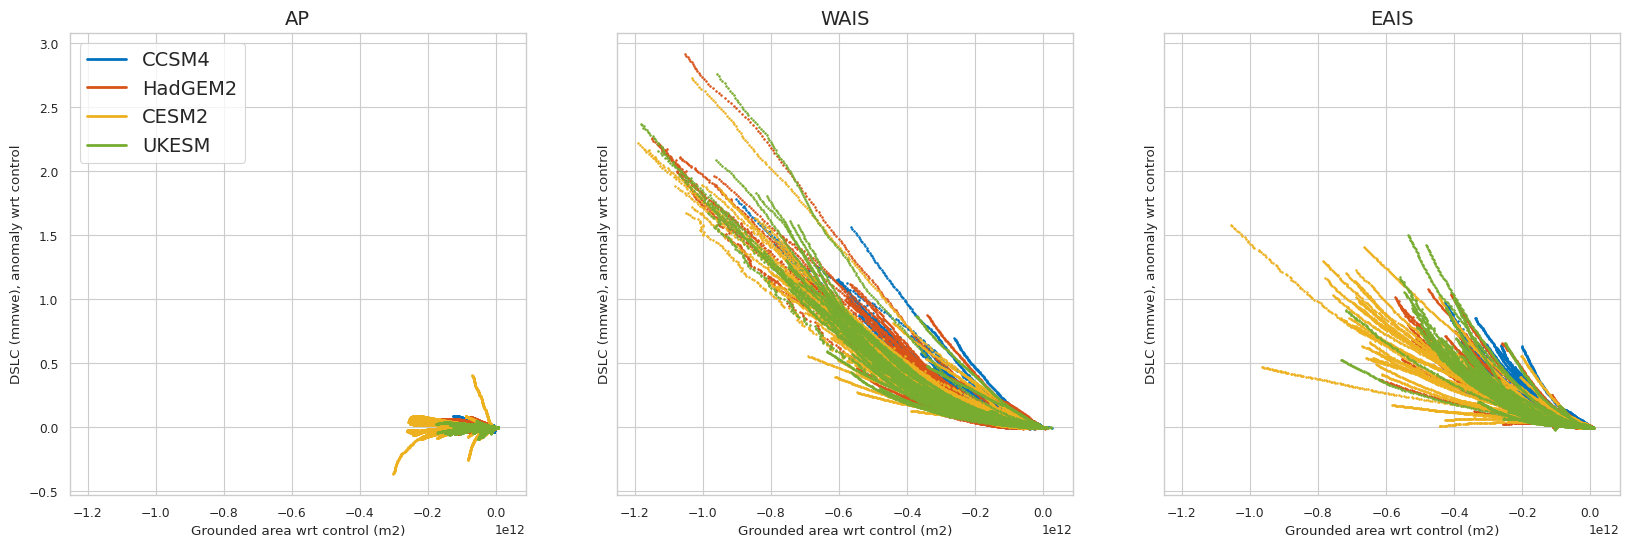

In [24]:
f,ax = plt.subplots(1,3, figsize = (20,6), sharey = True,sharex =True)

# Plot all experiments for AP
for iexp, expname in enumerate(expnames):
    dslc = dic_dslc_ap[expname]
    ga = dic_ga_ap[expname]

    for ism in dslc:
        ax[0].scatter(ga[ism],dslc[ism],s=1,color=colors[iexp])
        ax[0].set_ylabel('DSLC (mmwe), anomaly wrt control')
        ax[0].set_xlabel('Grounded area wrt control (m2)')

# Plot all experiments for WAIS
for iexp, expname in enumerate(expnames):
    dslc = dic_dslc_wais[expname]
    ga = dic_ga_wais[expname]

    for ism in dslc:
        ax[1].scatter(ga[ism],dslc[ism],s=1,color=colors[iexp])
        ax[1].set_ylabel('DSLC (mmwe), anomaly wrt control')
        ax[1].set_xlabel('Grounded area wrt control (m2)')

# Plot all experiments for EAIS
for iexp, expname in enumerate(expnames):
    dslc = dic_dslc_eais[expname]
    ga = dic_ga_eais[expname]

    for ism in dslc:
        ax[2].scatter(ga[ism],dslc[ism],s=1,color=colors[iexp])
        ax[2].set_ylabel('DSLC (mmwe), anomaly wrt control')
        ax[2].set_xlabel('Grounded area wrt control (m2)')

ax[0].set_title('AP',fontsize=14)
ax[1].set_title('WAIS',fontsize=14)
ax[2].set_title('EAIS',fontsize=14)

legend_lines = [mlines.Line2D([], [], color=colors[i], linewidth=2, label=expname) for i, expname in enumerate(expnames_plot)]
ax[0].legend(handles=legend_lines, loc='upper left', fontsize=14)

plt.show()

## Plot grounded area vs DSLC by sector


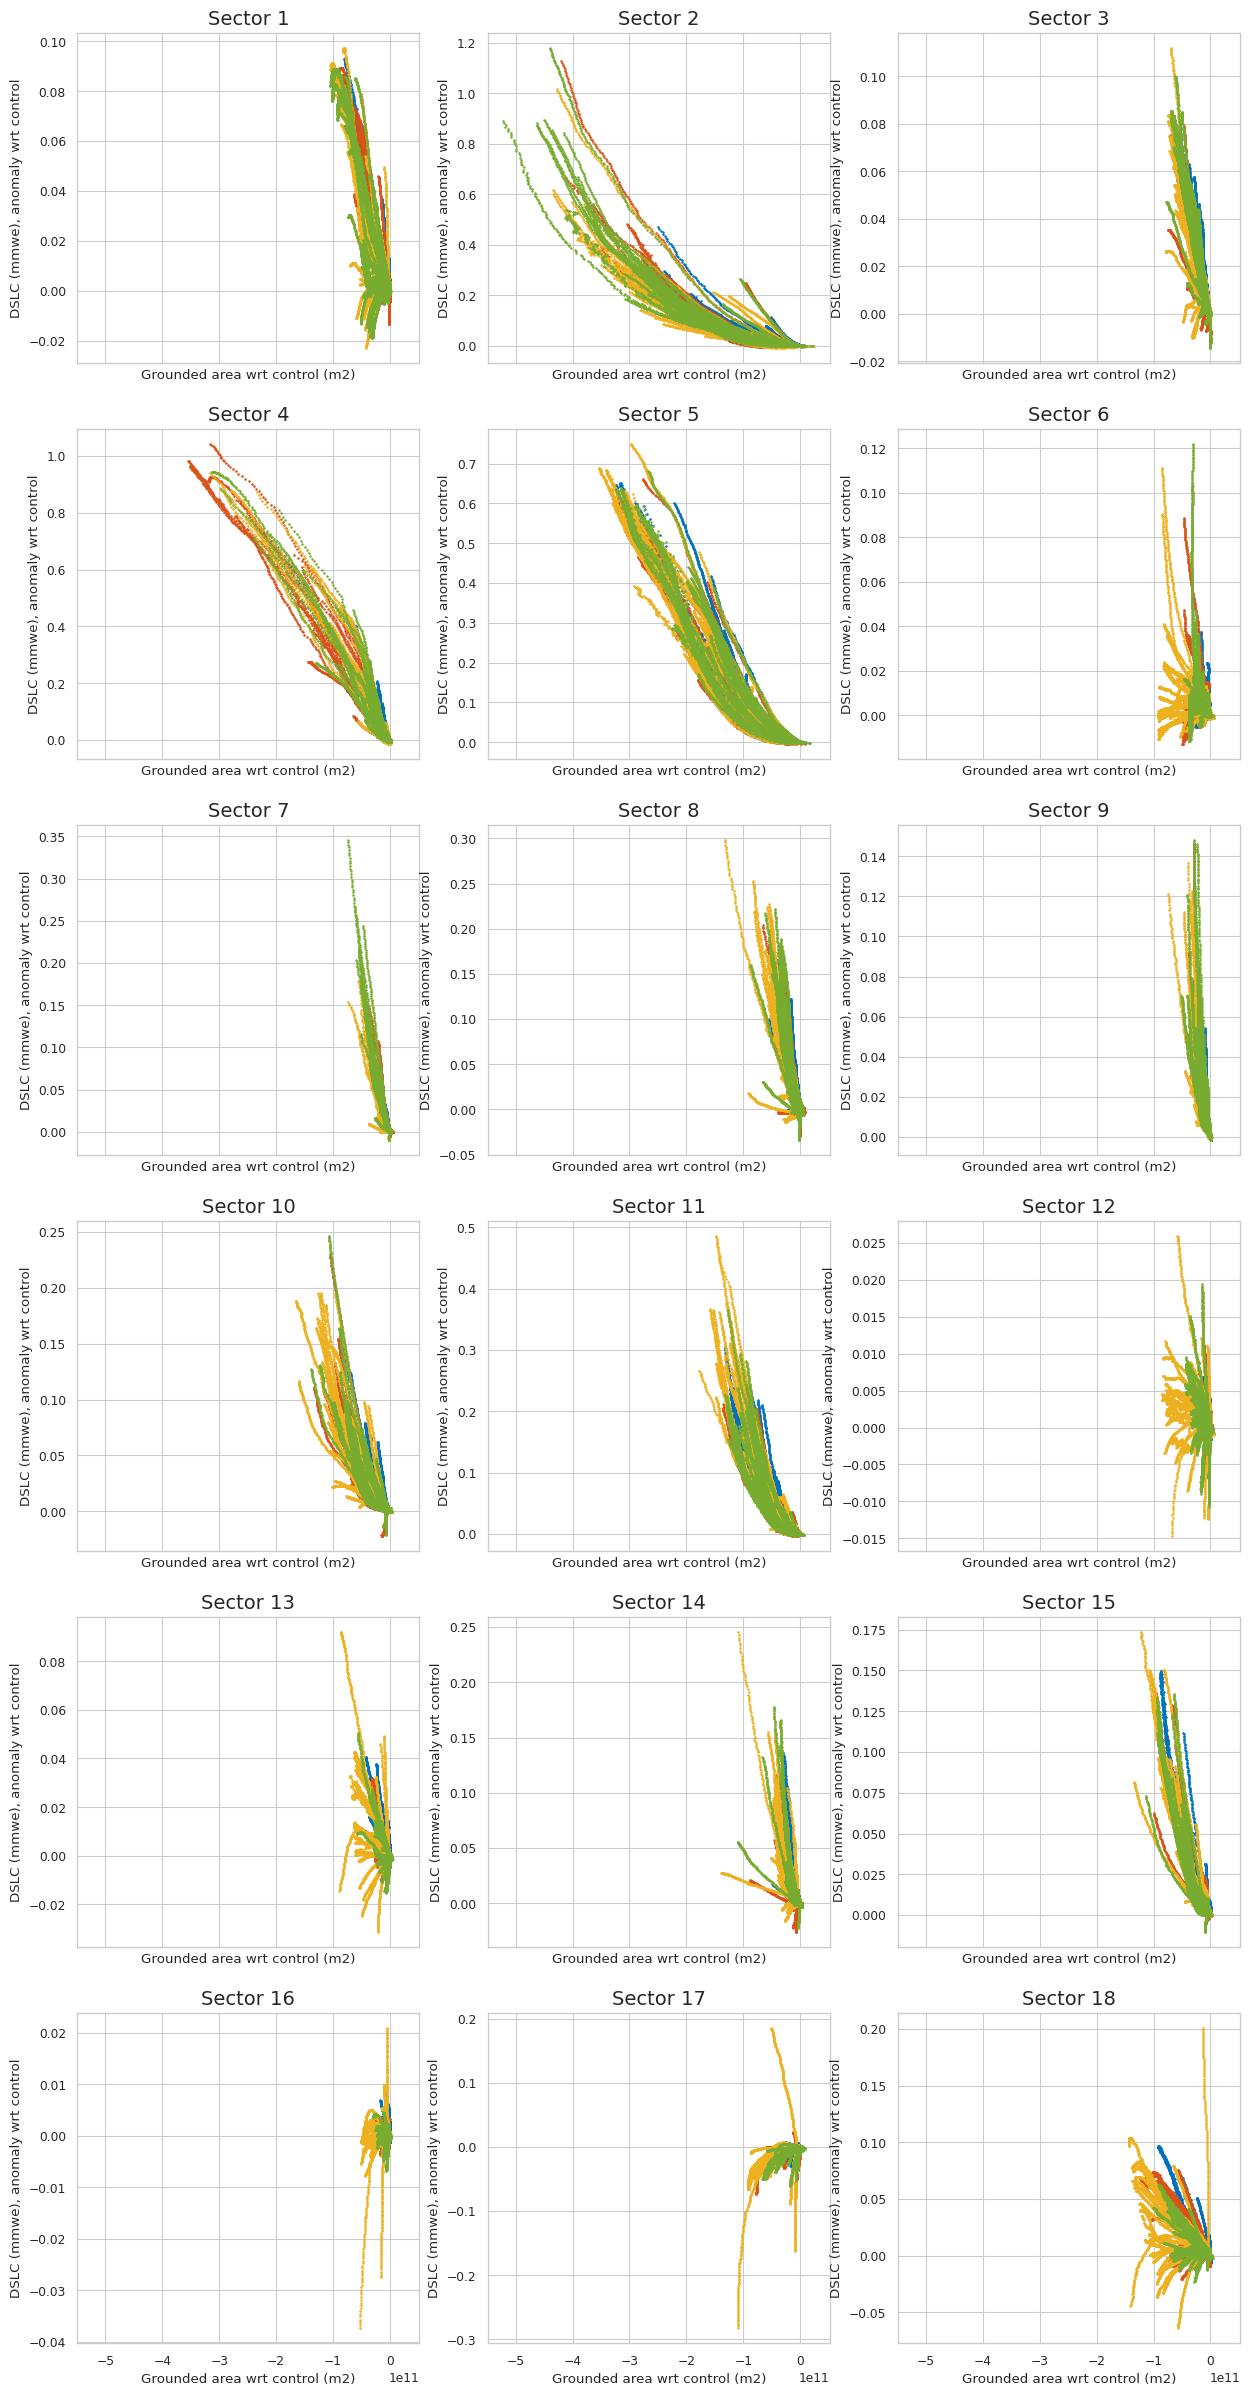

In [25]:
f, ax = plt.subplots(6, 3, figsize=(15, 30), sharey=False, sharex=True)
ax = ax.flatten()

# loop through sectors

for i_sec in range(18):
    for iexp, expname in enumerate(expnames):
        dslc = dic_dslc_secs[i_sec][expname]
        ga = dic_ga_secs[i_sec][expname]
    
        for ism in dslc:
            ax[i_sec].scatter(ga[ism],dslc[ism],s=1,color=colors[iexp])
            ax[i_sec].set_ylabel('DSLC (mmwe), anomaly wrt control')
            ax[i_sec].set_xlabel('Grounded area wrt control (m2)')
    ax[i_sec].set_title('Sector ' + str(i_sec+1), fontsize=14)


## Plot grounded area change vs DSLC at 2300

Compare the final grounded area change against DSLC (both datasets are anomalies wrt control), for different ice sheet models.

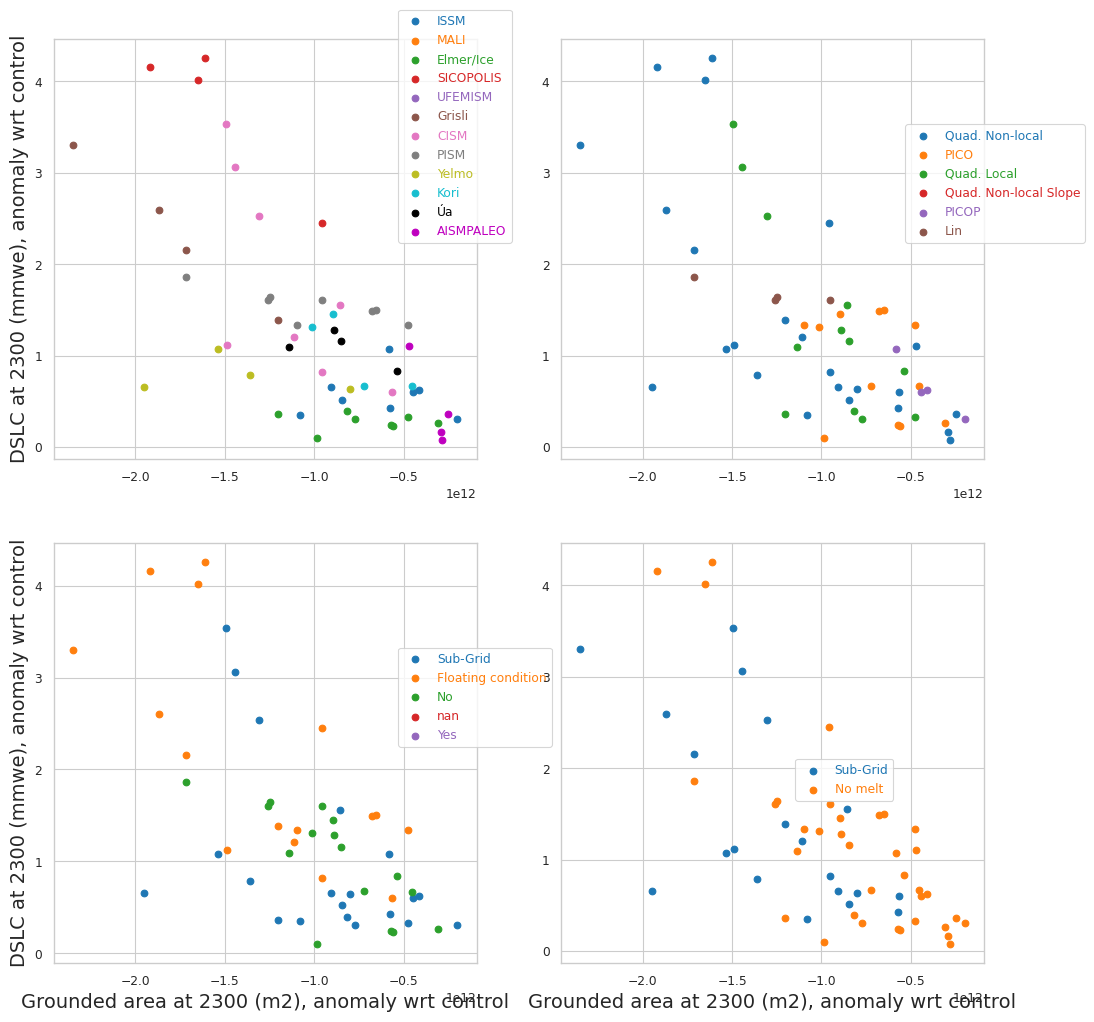

In [26]:
f,ax = plt.subplots(2,2, figsize = (12,12))
colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'k', 'm']
modelcolor = {}
meltcolor = {}
glcolor = {}
glmcolor = {}

for i, name in enumerate(df['Model'].unique()):
    modelcolor[name] = colors[i]
    ax[0,0].scatter(df.loc[(df['Model']==name),'ga2300'],df.loc[(df['Model']==name),'dslc2300'],c=modelcolor[name])
    ax[0,0].legend(modelcolor.keys(), frameon = True,loc = 0,bbox_to_anchor=[0.8, 0.5],labelcolor=colors)

for i, name in enumerate(df['Melt parameterisation'].unique()):
    meltcolor[name] = colors[i]
    ax[0,1].scatter(df.loc[(df['Melt parameterisation']==name),'ga2300'],df.loc[(df['Melt parameterisation']==name),'dslc2300'],c=meltcolor[name])
    ax[0,1].legend(meltcolor.keys(), frameon = True,loc = 0,bbox_to_anchor=[0.8, 0.5],labelcolor=colors)

for i, name in enumerate(df['GL treatment'].unique()):
    glcolor[name] = colors[i]
    ax[1,0].scatter(df.loc[(df['GL treatment']==name),'ga2300'],df.loc[(df['GL treatment']==name),'dslc2300'],c=glcolor[name])
    ax[1,0].legend(glcolor.keys(), frameon = True,loc = 0,bbox_to_anchor=[0.8, 0.5],labelcolor=colors)

for i, name in enumerate(df['GL melt'].unique()):
    glmcolor[name] = colors[i]
    ax[1,1].scatter(df.loc[(df['GL melt']==name),'ga2300'],df.loc[(df['GL melt']==name),'dslc2300'],c=glmcolor[name])
    ax[1,1].legend(glmcolor.keys(), frameon = True,loc = 0,bbox_to_anchor=[0.8, 0.5],labelcolor=colors)

ax[1,0].set_xlabel('Grounded area at 2300 (m2), anomaly wrt control', fontsize=14)
ax[1,1].set_xlabel('Grounded area at 2300 (m2), anomaly wrt control', fontsize=14)
ax[0,0].set_ylabel('DSLC at 2300 (mmwe), anomaly wrt control', fontsize=14)
ax[1,0].set_ylabel('DSLC at 2300 (mmwe), anomaly wrt control', fontsize=14)
plt.show()